# **Penting**
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Hapus simbol pagar (#) jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan

# **INFORMASI DATASET**
## Latar Belakang

Dalam dunia bisnis ritel, pemahaman terhadap perilaku pelanggan menjadi salah satu faktor krusial dalam menentukan strategi pemasaran, peningkatan layanan, serta pengambilan keputusan berbasis data. Salah satu pendekatan yang umum digunakan untuk memahami perilaku pelanggan adalah melalui segmentasi, yaitu proses pengelompokan pelanggan ke dalam beberapa segmen atau kelompok berdasarkan karakteristik tertentu.

Dengan menerapkan metode **unsupervised learning**, khususnya **clustering**, proyek ini bertujuan untuk membentuk segmentasi pelanggan yang merepresentasikan pola-pola pembelian yang serupa. Hasil segmentasi ini diharapkan dapat memberikan insight yang bernilai bagi pihak manajemen, khususnya dalam menyusun strategi promosi yang lebih tepat sasaran, mengembangkan program loyalitas, serta mengoptimalkan layanan pelanggan.

# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [271]:
#Type your code here

import pandas as pd
import numpy as np
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

In [272]:
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)

In [273]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [274]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [275]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

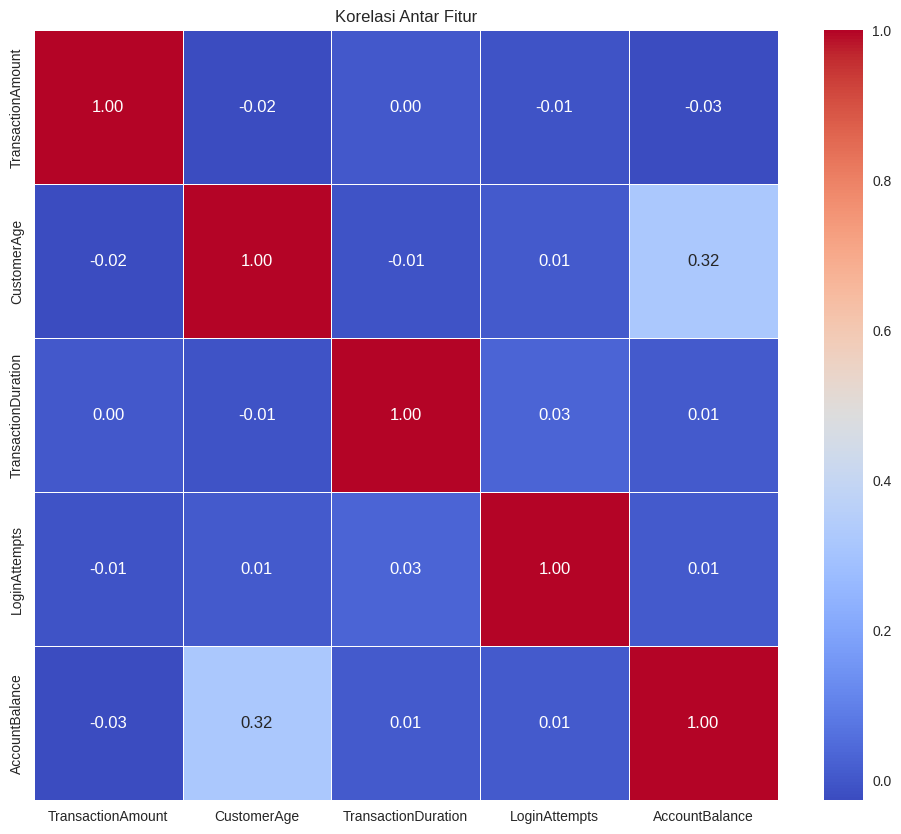

In [276]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
num_features = df[['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']]

plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Antar Fitur')
plt.show()

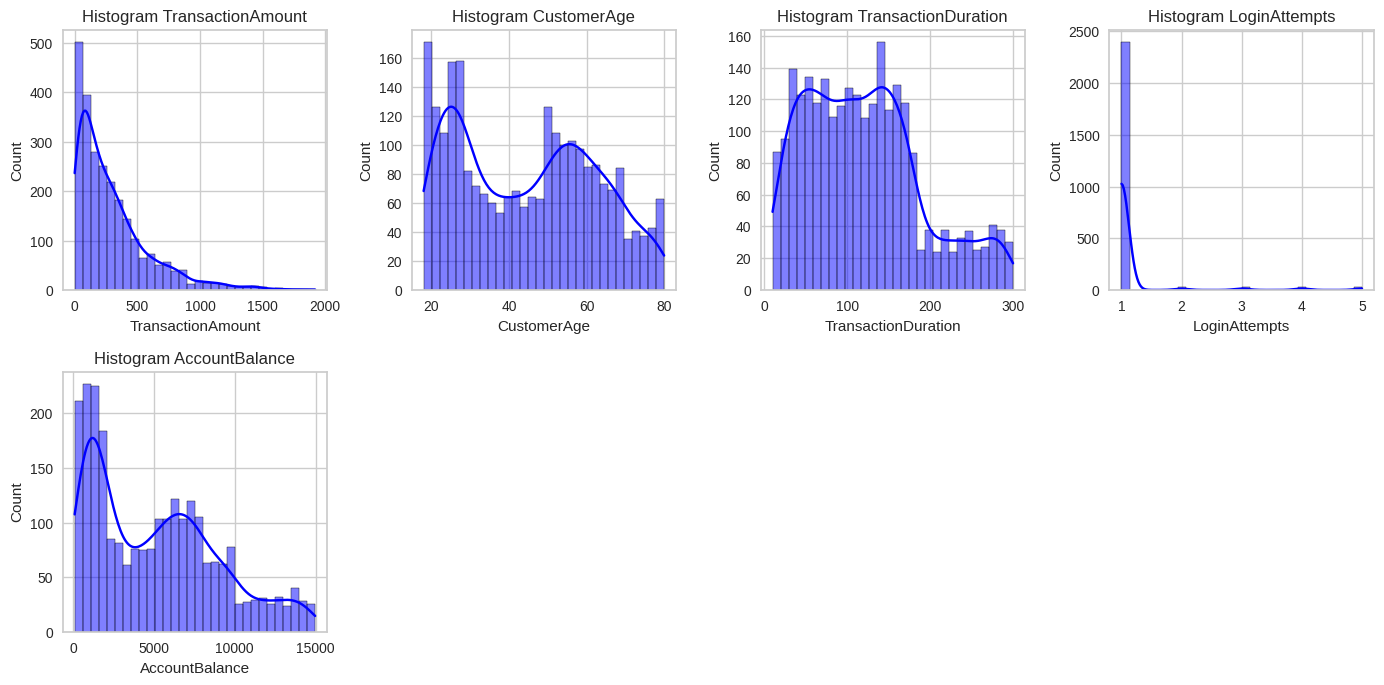

In [277]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
  plt.subplot(3, 4, i)
  sns.histplot(df[column], bins=30, kde=True, color='blue')
  plt.title(f"Histogram {column}")
plt.tight_layout()
plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

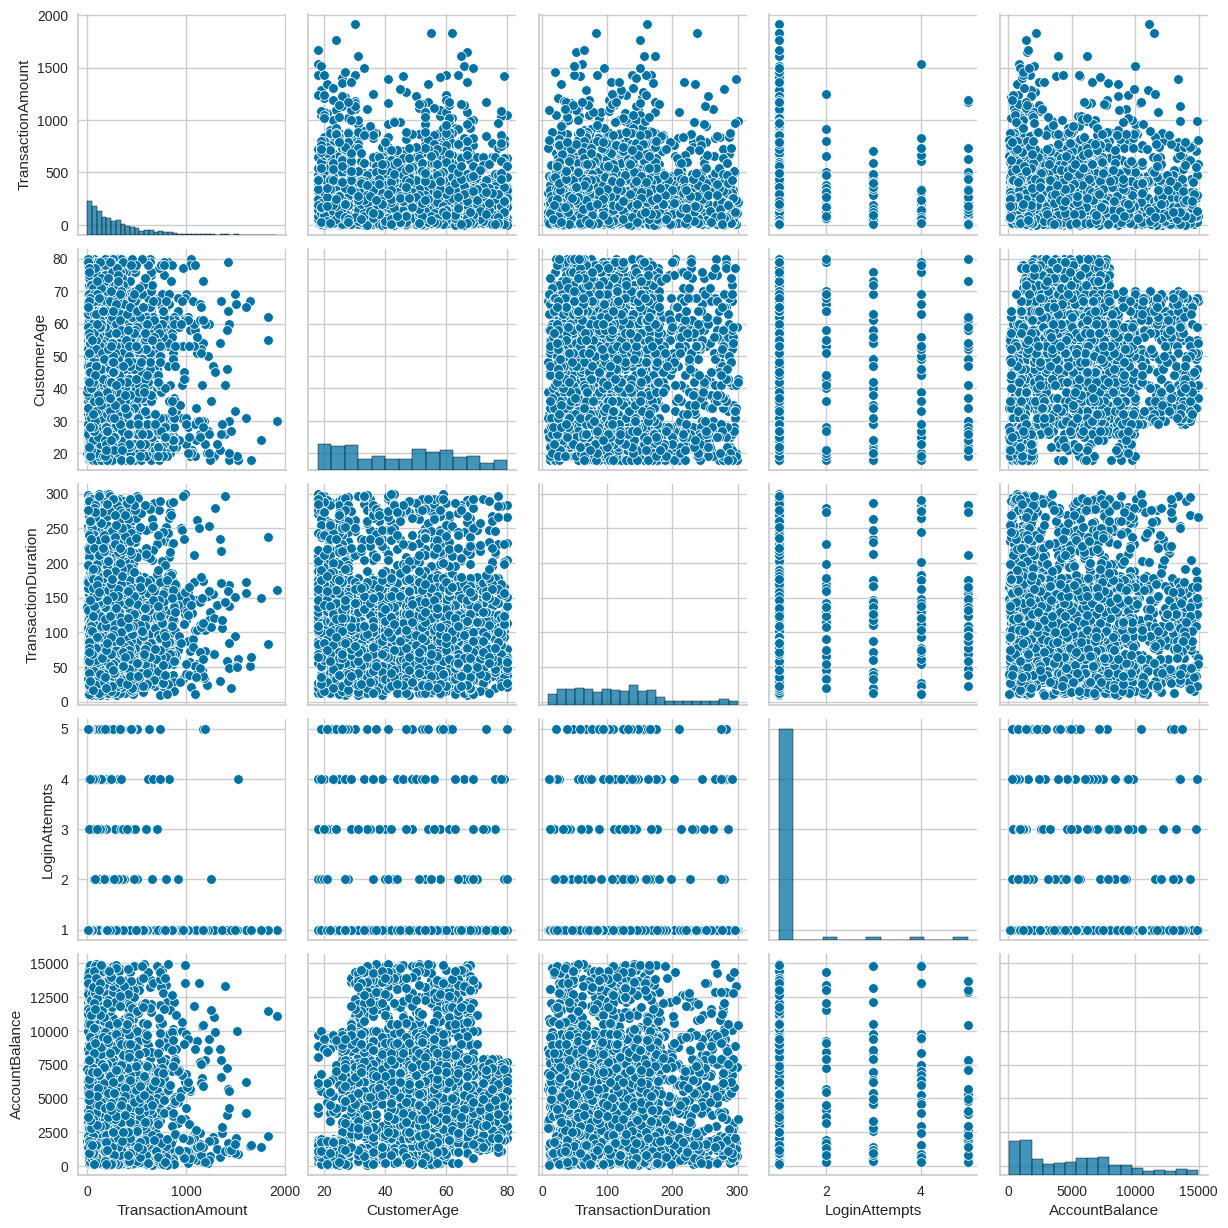

In [278]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)

sns.pairplot(num_features)
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `pd.get_dummies()` atau `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [279]:
# Mengecek dataset menggunakan isnull().sum()

print(df.isnull().sum())

TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64


In [280]:
# Mengecek dataset menggunakan duplicated().sum()

print(df.duplicated().sum())

21


In [281]:
# Menghapus data duplikat menggunakan drop_duplicates().

df = df.drop_duplicates()

In [282]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).

df = df.dropna()

In [283]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.

numerical_features = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']

scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized[numerical_features] = scaler.fit_transform(df[numerical_features])

df_normalized.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,0.007554,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,0.838710,Doctor,0.244828,0.0,0.336790,2024-11-04 08:08:08
1,TX000002,AC00455,0.205368,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,0.806452,Doctor,0.451724,0.0,0.918049,2024-11-04 08:09:35
2,TX000003,AC00019,0.068840,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,0.016129,Student,0.158621,0.0,0.068578,2024-11-04 08:07:04
3,TX000004,AC00070,0.100636,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,0.129032,Student,0.051724,0.0,0.569170,2024-11-04 08:09:06
5,TX000006,AC00393,0.050192,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,0.000000,Student,0.558621,0.0,0.045677,2024-11-04 08:06:36


In [284]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address

df_normalized = df_normalized.drop(columns=['TransactionID',
                      'AccountID',
                      'DeviceID',
                      'IP Address',
                      'MerchantID'
                      ])
df_normalized.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007554,2023-04-11 16:29:14,Debit,San Diego,ATM,0.838710,Doctor,0.244828,0.0,0.336790,2024-11-04 08:08:08
1,0.205368,2023-06-27 16:44:19,Debit,Houston,ATM,0.806452,Doctor,0.451724,0.0,0.918049,2024-11-04 08:09:35
2,0.068840,2023-07-10 18:16:08,Debit,Mesa,Online,0.016129,Student,0.158621,0.0,0.068578,2024-11-04 08:07:04
3,0.100636,2023-05-05 16:32:11,Debit,Raleigh,Online,0.129032,Student,0.051724,0.0,0.569170,2024-11-04 08:09:06
5,0.050192,2023-04-03 17:15:01,Debit,Oklahoma City,ATM,0.000000,Student,0.558621,0.0,0.045677,2024-11-04 08:06:36


In [285]:
# Melakukan feature encoding menggunakan pd.get_dummies() atau LabelEncoder() untuk fitur kategorikal.

cat_columns = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']

label_encoder = LabelEncoder()
df_encoded = df_normalized.copy()

for column in cat_columns:
  df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

df_encoded.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,0.007554,2023-04-11 16:29:14,1,36,0,0.838710,0,0.244828,0.0,0.336790,2024-11-04 08:08:08
1,0.205368,2023-06-27 16:44:19,1,15,0,0.806452,0,0.451724,0.0,0.918049,2024-11-04 08:09:35
2,0.068840,2023-07-10 18:16:08,1,23,2,0.016129,3,0.158621,0.0,0.068578,2024-11-04 08:07:04
3,0.100636,2023-05-05 16:32:11,1,33,2,0.129032,3,0.051724,0.0,0.569170,2024-11-04 08:09:06
5,0.050192,2023-04-03 17:15:01,1,28,0,0.000000,3,0.558621,0.0,0.045677,2024-11-04 08:06:36


(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [286]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.

In [287]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder atau get_dummies.

# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
2. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
3. Jalankan cell code `joblib.dump(model_kmeans, "best_model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [288]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df_encoded.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000,2135.000000
mean,0.162684,0.773302,21.251991,0.978923,0.429402,1.503044,0.379837,0.029391,0.335537
std,0.158930,0.418794,12.302811,0.807083,0.287665,1.135961,0.244355,0.144556,0.263494
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.045219,1.000000,11.000000,0.000000,0.145161,0.000000,0.182759,0.000000,0.092778
50%,0.116383,1.000000,21.000000,1.000000,0.435484,1.000000,0.355172,0.000000,0.304936
75%,0.226338,1.000000,32.000000,2.000000,0.661290,3.000000,0.524138,0.000000,0.510542
max,1.000000,1.000000,42.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000


In [289]:
# Mengambil kolom 'CustomerAge' dan 'AccountBalance' dari dataset dan menyimpannya dalam array X
X = df_encoded.iloc[:, [5, 9]].values

# Menampilkan data yang diambil dalam format dataframe dengan nama kolom yang sesuai
print(pd.DataFrame(X, columns=['CustomerAge', 'AccountBalance']))

      CustomerAge  AccountBalance
0        0.838710        0.336790
1        0.806452        0.918049
2        0.016129        0.068578
3        0.129032        0.569170
4        0.000000        0.045677
...           ...             ...
2130     0.080645        0.112580
2131     0.096774        0.001953
2132     0.935484        0.323145
2133     0.306452        0.442845
2134     0.145161        0.073534

[2135 rows x 2 columns]


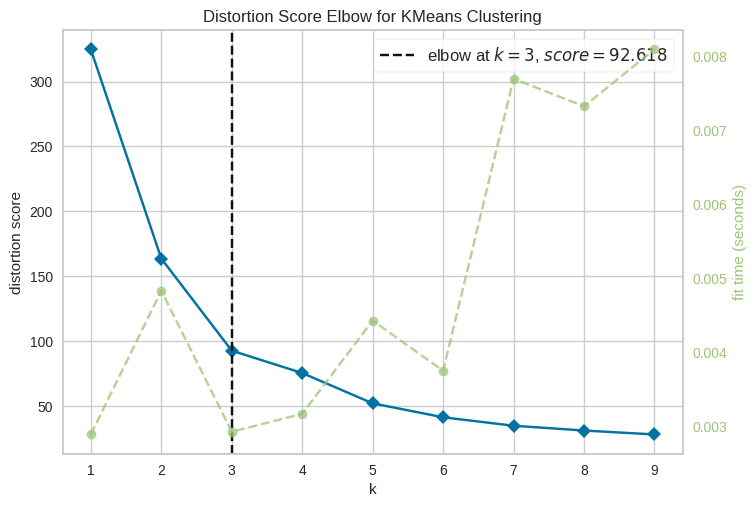

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [290]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k=(1, 10))
visualizer.fit(X)
visualizer.show()

In [291]:
# Menggunakan algoritma K-Means Clustering

# Inisialisasi dan melatih model KMeans dengan jumlah cluster = 3
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

# Mendapatkan label cluster
labels = kmeans.labels_

# Mendapatkan jumlah cluster
k = 3

df['Cluster'] = labels

# Fungsi untuk analisis karakteristik cluster
def analyze_clusters(df, k):
    print('Analisis Karakteristik Setiap Cluster (Data Asli):')
    for cluster_id in range(k):
        cluster_data = df[df['Cluster'] == cluster_id]

        mean_customer_age = cluster_data['CustomerAge'].mean()
        mean_account_balance = cluster_data['AccountBalance'].mean()

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata Customer Age (Umur): {mean_customer_age:.0f}")
        print(f"Rata-rata Account Balance (Saldo): {mean_account_balance:.2f}")

analyze_clusters(df, 3)

Analisis Karakteristik Setiap Cluster (Data Asli):

Cluster 1:
Rata-rata Customer Age (Umur): 45
Rata-rata Account Balance (Saldo): 9896.75

Cluster 2:
Rata-rata Customer Age (Umur): 26
Rata-rata Account Balance (Saldo): 1764.04

Cluster 3:
Rata-rata Customer Age (Umur): 62
Rata-rata Account Balance (Saldo): 4362.17


In [292]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Cluster
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,2
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,0
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,1
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,0
5,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 08:06:36,1


Jalankan cell code ini untuk menyimpan model kamu.

In [293]:
# Menyimpan model menggunakan joblib

import joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [294]:
# Menghitung dan menampilkan nilai Silhouette Score.

sil_score = silhouette_score(X, labels)
print(f"Silhouette Score: {sil_score:.2f}")

Silhouette Score: 0.49


(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [295]:
# Membangun model menggunakan PCA.

In [296]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# joblib.dump(___, "PCA_model_clustering.h5")

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**

### **Cluster 0: (Nasabah Paruh Baya dengan Saldo Tinggi dan Aktivitas Stabil)**

* **Rata-rata (mean) Transaction Amount:** 286.43 (rentang: 0.32 – 1831.02)
* **Rata-rata (mean) Customer Age:** 45.08 tahun (rentang: 18 – 70)
* **Rata-rata (mean) Transaction Duration:** 121.94 detik (rentang: 10 – 300)
* **Rata-rata (mean) Login Attempts:** 1.11 kali (rentang: 1 – 5)
* **Rata-rata (mean) Account Balance:** 9,896.75 (rentang: 5,298.85 – 14,977.99)
* **Transaksi dominan:** Debit
* **Lokasi dominan:** Las Vegas
* **Channel dominan:** Branch
* **Pekerjaan dominan:** Doctor

**Analisis:**
Cluster ini terdiri dari nasabah paruh baya dengan saldo akun yang cukup tinggi dan perilaku transaksi yang stabil. Mereka cenderung mengunjungi cabang langsung (branch) untuk melakukan transaksi, menunjukkan preferensi pada pelayanan langsung. Cocok ditawarkan layanan keuangan tingkat lanjut seperti deposito berjangka, asuransi kesehatan, dan program konsultasi keuangan pribadi.

---

### **Cluster 1: (Nasabah Muda dengan Saldo Rendah dan Aktivitas Rendah)**

* **Rata-rata (mean) Transaction Amount:** 308.03 (rentang: 0.26 – 1762.28)
* **Rata-rata (mean) Customer Age:** 26.11 tahun (rentang: 18 – 47)
* **Rata-rata (mean) Transaction Duration:** 121.02 detik (rentang: 10 – 300)
* **Rata-rata (mean) Login Attempts:** 1.12 kali (rentang: 1 – 5)
* **Rata-rata (mean) Account Balance:** 1,764.04 (rentang: 102.20 – 8,086.04)
* **Transaksi dominan:** Debit
* **Lokasi dominan:** Miami
* **Channel dominan:** Branch
* **Pekerjaan dominan:** Student

**Analisis:**
Cluster ini mencerminkan kelompok nasabah muda dengan saldo rendah dan keterlibatan digital yang rendah. Mereka masih berada pada fase awal dalam siklus keuangan. Potensi besar untuk diberikan edukasi keuangan, ditawari rekening tabungan pemula, serta promo atau insentif berbasis penggunaan produk dasar perbankan.

---

### **Cluster 2: (Nasabah Lansia dengan Saldo Menengah dan Aktif di ATM)**

* **Rata-rata (mean) Transaction Amount:** 298.08 (rentang: 0.84 – 1830.00)
* **Rata-rata (mean) Customer Age:** 62.20 tahun (rentang: 43 – 80)
* **Rata-rata (mean) Transaction Duration:** 117.84 detik (rentang: 10 – 299)
* **Rata-rata (mean) Login Attempts:** 1.12 kali (rentang: 1 – 5)
* **Rata-rata (mean) Account Balance:** 4,362.17 (rentang: 120.89 – 9,127.65)
* **Transaksi dominan:** Debit
* **Lokasi dominan:** Charlotte
* **Channel dominan:** ATM
* **Pekerjaan dominan:** Retired

**Analisis:**
Cluster ini berisi nasabah yang sudah lanjut usia dengan saldo menengah dan aktivitas rutin melalui ATM. Mereka tampaknya sudah pensiun dan menggunakan layanan dasar perbankan. Layanan yang tepat: tabungan pensiun, program loyalitas berbasis usia, serta fitur keamanan tambahan untuk transaksi ATM.

---

In [297]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan modus untuk fitur kategorikal.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.

cluster_summary = df.groupby('Cluster')[numerical_features].agg(['mean', 'min', 'max'])

# Tampilkan hasil
print(cluster_summary)

        TransactionAmount                CustomerAge              \
                     mean   min      max        mean   min   max   
Cluster                                                            
0              286.434825  0.32  1831.02   45.080952  18.0  70.0   
1              308.026815  0.26  1762.28   26.112011  18.0  47.0   
2              298.080537  0.84  1830.00   62.198953  43.0  80.0   

        TransactionDuration              LoginAttempts            \
                       mean   min    max          mean  min  max   
Cluster                                                            
0                121.938095  10.0  300.0      1.114286  1.0  5.0   
1                121.024291  10.0  300.0      1.117409  1.0  5.0   
2                117.835079  10.0  299.0      1.120419  1.0  5.0   

        AccountBalance                     
                  mean      min       max  
Cluster                                    
0          9896.749413  5298.85  14977.99  
1     

In [298]:
# Hitung modus (mode) per cluster untuk fitur kategorikal
mode_summary = df.groupby('Cluster')[cat_columns].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

# Tampilkan hasil
print(mode_summary)

        TransactionType   Location Channel CustomerOccupation
Cluster                                                      
0                 Debit  Las Vegas  Branch             Doctor
1                 Debit      Miami  Branch            Student
2                 Debit  Charlotte     ATM            Retired


# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [299]:
# Ekspor df_encoded untuk klasifikasi

df_encoded['Cluster'] = kmeans.labels_

In [300]:
# Pastikan nama kolom clustering sudah diubah menjadi Target

df_encoded.rename(columns={'Cluster': 'Target'}, inplace=True)

In [301]:
# Simpan Data

df_encoded.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [302]:
# inverse dataset ke rentang normal

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1. **Cluster 1: (___)**:
  - **Rata-rata (mean) <Fitur>:** <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Cluster ini ...

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [303]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.

In [304]:
# Simpan Data
# ___.to_csv('data_clustering_inverse.csv', index=False)